# Лабораторная работа: Singular Value Decomposition (SVD)

Часть 1. Четыре фундаментальных подпространства
Ранг матрицы: 2

Пространство столбцов (базис):
[[-0.273 -0.725]
 [-0.353 -0.419]
 [-0.433 -0.113]
 [-0.513  0.193]
 [-0.593  0.499]]

Левое нуль-пространство (базис):
[[ 0.036 -0.533  0.338]
 [-0.35   0.279 -0.707]
 [ 0.735  0.497  0.115]
 [-0.562  0.304  0.54 ]
 [ 0.142 -0.546 -0.286]]

Пространство строк (базис):
[[-0.271 -0.351 -0.431 -0.511 -0.592 -0.08 ]
 [ 0.7    0.41   0.119 -0.172 -0.462 -0.291]]

Правое нуль-пространство (базис):
[[-0.653  0.581  0.342 -0.095 -0.175 -0.281]
 [ 0.047  0.482 -0.561 -0.457  0.488  0.057]
 [-0.017  0.286  0.057 -0.003 -0.323  0.9  ]
 [-0.084  0.239 -0.605  0.701 -0.251 -0.127]]

Проверка: A * (базис правого нуль-пространства)^T ≈ 0
[[ 0. -0.  0.  0.]
 [ 0. -0.  0.  0.]
 [ 0. -0.  0.  0.]
 [ 0. -0.  0.  0.]
 [ 0. -0.  0.  0.]]

Часть 2. Полное vs экономное SVD

--- Случай 1: высокая и худая матрица (5x2) ---
Полное SVD: U=(5, 5), Sigma=(2,), V=(2, 2)
Экономное SVD: U=(5, 2), Sigma=(2,), V=(2, 2)
U^T 

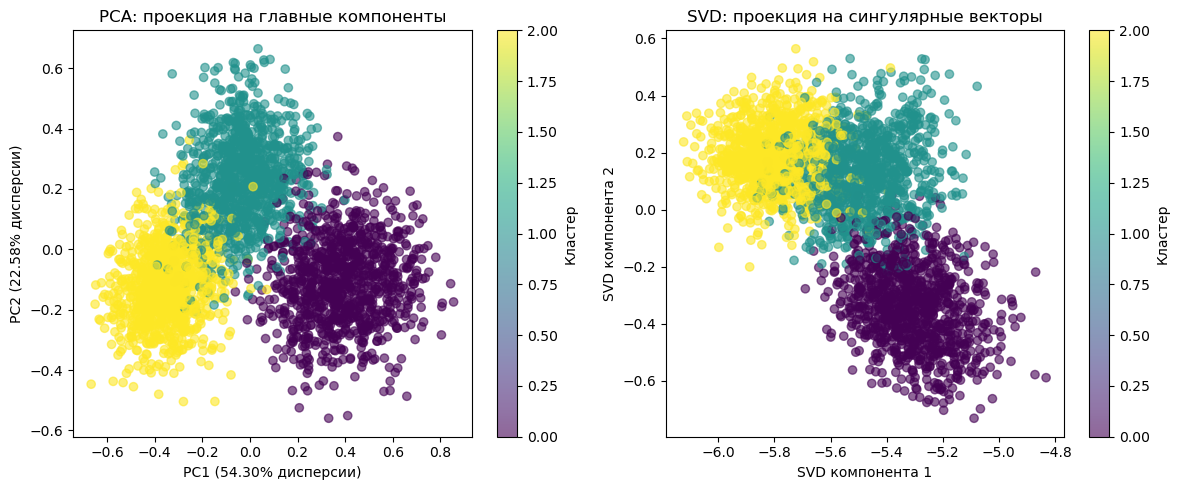


Объясненная дисперсия:
  PC1: 54.30%
  PC2: 22.58%
  Сумма первых двух: 76.88%

Часть 4. Построение псевдообратной матрицы
Корреляционная матрица ≈ SVD-приближение: True

Обратная матрица через SVD:
  Размерность: (5, 3000)
  X · X⁺ · X = X: True
  X⁺ · X · X⁺ = X⁺: True
  Совпадение с np.linalg.pinv: True

Решение системы X·β = y через псевдообратную:
  Норма невязки ||Xβ - y||: 54.026495
  Совпадение с lstsq: True

Часть 5. Аппроксимация матрицы низкого ранга (теорема Эккарта-Янга)
Ранг 1: относительная ошибка = 0.0682 (6.82%)
Ранг 2: относительная ошибка = 0.0478 (4.78%)
Ранг 3: относительная ошибка = 0.0319 (3.19%)
Ранг 4: относительная ошибка = 0.0206 (2.06%)


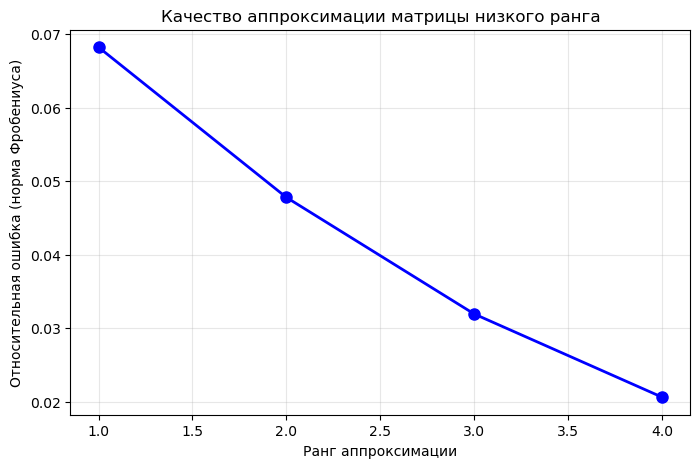


ВЫВОДЫ

1. SVD позволяет разложить любую матрицу на произведение трех матриц:
   UΣV^T, где U и V ортогональны, а Σ диагональна.

2. Экономное SVD экономит память и время вычислений, особенно 
   для больших матриц, сохраняя при этом всю информацию.

3. PCA является частным случаем SVD центрированных данных и позволяет:
   - снизить размерность данных
   - визуализировать многомерные данные
   - выделить наиболее важные признаки

4. Теорема Эккарта-Янга гарантирует, что усеченное SVD дает 
   наилучшее приближение матрицы заданного ранга.


Лабораторная работа выполнена успешно!


In [1]:
import numpy as np
import numpy.linalg as LA
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


print("=" * 60)
print("Часть 1. Четыре фундаментальных подпространства")
print("=" * 60)

# Задаем матрицу
A = np.array([[1, 2, 3, 4, 5, 1],
              [2, 3, 4, 5, 6, 1],
              [3, 4, 5, 6, 7, 1],
              [4, 5, 6, 7, 8, 1],
              [5, 6, 7, 8, 9, 1]])

# Вычисляем SVD
U, S, VT = np.linalg.svd(A)

# Вычисляем ранг
p = np.linalg.matrix_rank(A)

# Выделяем подпространства
UL = U[:, :p]      
UR = U[:, p:]      
VL = VT[:p, :]     
VR = VT[p:, :]     

print(f"Ранг матрицы: {p}")
print("\nПространство столбцов (базис):")
print(UL.round(3))
print("\nЛевое нуль-пространство (базис):")
print(UR.round(3))
print("\nПространство строк (базис):")
print(VL.round(3))
print("\nПравое нуль-пространство (базис):")
print(VR.round(3))

print("\nПроверка: A * (базис правого нуль-пространства)^T ≈ 0")
print((A @ VR.T).round(10))


print("\n" + "=" * 60)
print("Часть 2. Полное vs экономное SVD")
print("=" * 60)

print("\n--- Случай 1: высокая и худая матрица (5x2) ---")
X_tall = np.random.rand(5, 2)
U_full, S_full, V_full = np.linalg.svd(X_tall)
U_eco, S_eco, V_eco = np.linalg.svd(X_tall, full_matrices=False)

print(f"Полное SVD: U={U_full.shape}, Sigma={S_full.shape}, V={V_full.shape}")
print(f"Экономное SVD: U={U_eco.shape}, Sigma={S_eco.shape}, V={V_eco.shape}")

print(f"U^T U (полное) = {np.allclose(U_full.T @ U_full, np.eye(5))}")
print(f"U^T U (экономное) = {np.allclose(U_eco.T @ U_eco, np.eye(2))}")

print("\n--- Случай 2: короткая и толстая матрица (2x5) ---")
X_short = np.random.rand(2, 5)
U_full, S_full, V_full = np.linalg.svd(X_short)
U_eco, S_eco, V_eco = np.linalg.svd(X_short, full_matrices=False)

print(f"Полное SVD: U={U_full.shape}, Sigma={S_full.shape}, V={V_full.shape}")
print(f"Экономное SVD: U={U_eco.shape}, Sigma={S_eco.shape}, V={V_eco.shape}")

print(f"V V^T (полное) = {np.allclose(V_full @ V_full.T, np.eye(5))}")
print(f"V V^T (экономное) = {np.allclose(V_eco @ V_eco.T, np.eye(2))}")


X_reconstructed = U_eco @ np.diag(S_eco) @ V_eco
print(f"Точность восстановления: {np.allclose(X_short, X_reconstructed)}")

print("\n" + "=" * 60)
print("Часть 3. PCA через SVD и визуализация")
print("=" * 60)

X, labels = make_blobs(n_samples=3000, n_features=5, centers=3, 
                        random_state=42, cluster_std=1.5)
X = np.log(np.abs(X) + 6) 

class DecomAnalysis:
    
    def __init__(self, n_components=2):
        self.n_components = n_components
        
    def fit(self, X):
        self.mean = X.mean(axis=0, keepdims=True)
        X_centered = X - self.mean
        
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
        self.U_pca = U[:, :self.n_components]
        self.S_pca = S[:self.n_components]
        self.V_pca = Vt[:self.n_components, :].T
        
        var = (S ** 2) / (len(X) - 1)
        self.explained_variance_ratio_ = var[:self.n_components] / var.sum()
        
        U, S, Vt = np.linalg.svd(X, full_matrices=False)
        self.U_svd = U[:, :self.n_components]
        self.S_svd = S[:self.n_components]
        
        return self
    
    def transform_pca(self, X):
        X_centered = X - self.mean
        return X_centered @ self.V_pca
    
    def transform_svd(self, X):
        return self.U_svd * self.S_svd

# Обучаем модель
da = DecomAnalysis(n_components=2)
da.fit(X)

# Получаем проекции
pca_result = da.transform_pca(X)
svd_result = da.transform_svd(X)

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter1 = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                        c=labels, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({da.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({da.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.title('PCA: проекция на главные компоненты')
plt.colorbar(scatter1, label='Кластер')

plt.subplot(1, 2, 2)
scatter2 = plt.scatter(svd_result[:, 0], svd_result[:, 1], 
                        c=labels, cmap='viridis', alpha=0.6)
plt.xlabel('SVD компонента 1')
plt.ylabel('SVD компонента 2')
plt.title('SVD: проекция на сингулярные векторы')
plt.colorbar(scatter2, label='Кластер')

plt.tight_layout()
plt.show()

print(f"\nОбъясненная дисперсия:")
print(f"  PC1: {da.explained_variance_ratio_[0]:.2%}")
print(f"  PC2: {da.explained_variance_ratio_[1]:.2%}")
print(f"  Сумма первых двух: {da.explained_variance_ratio_.sum():.2%}")

print("\n" + "=" * 60)
print("Часть 4. Построение псевдообратной матрицы")
print("=" * 60)

U, S, Vt = np.linalg.svd(X, full_matrices=False)

corr = X.T @ X
corr_approx = Vt.T @ np.diag(S**2) @ Vt

print(f"Корреляционная матрица ≈ SVD-приближение: {np.allclose(corr, corr_approx)}")

X_pinv = Vt.T @ np.diag(1/S) @ U.T
X_pinv_direct = np.linalg.pinv(X)

print(f"\nОбратная матрица через SVD:")
print(f"  Размерность: {X_pinv.shape}")
print(f"  X · X⁺ · X = X: {np.allclose(X @ X_pinv @ X, X)}")
print(f"  X⁺ · X · X⁺ = X⁺: {np.allclose(X_pinv @ X @ X_pinv, X_pinv)}")
print(f"  Совпадение с np.linalg.pinv: {np.allclose(X_pinv, X_pinv_direct)}")

np.random.seed(42)
y = np.random.randn(X.shape[0])
beta_svd = X_pinv @ y
beta_direct = np.linalg.lstsq(X, y, rcond=None)[0]

print(f"\nРешение системы X·β = y через псевдообратную:")
print(f"  Норма невязки ||Xβ - y||: {np.linalg.norm(X @ beta_svd - y):.6f}")
print(f"  Совпадение с lstsq: {np.allclose(beta_svd, beta_direct)}")

print("\n" + "=" * 60)
print("Часть 5. Аппроксимация матрицы низкого ранга (теорема Эккарта-Янга)")
print("=" * 60)

ranks = [1, 2, 3, 4]
errors = []

for r in ranks:
    U_r = U[:, :r]
    S_r = np.diag(S[:r])
    Vt_r = Vt[:r, :]
    
    X_approx = U_r @ S_r @ Vt_r
    
    error = np.linalg.norm(X - X_approx, 'fro') / np.linalg.norm(X, 'fro')
    errors.append(error)
    print(f"Ранг {r}: относительная ошибка = {error:.4f} ({error*100:.2f}%)")

plt.figure(figsize=(8, 5))
plt.plot(ranks, errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Ранг аппроксимации')
plt.ylabel('Относительная ошибка (норма Фробениуса)')
plt.title('Качество аппроксимации матрицы низкого ранга')
plt.grid(True, alpha=0.3)
plt.show()

print("\n" + "=" * 60)
print("ВЫВОДЫ")
print("=" * 60)
print("""
1. SVD позволяет разложить любую матрицу на произведение трех матриц:
   UΣV^T, где U и V ортогональны, а Σ диагональна.

2. Экономное SVD экономит память и время вычислений, особенно 
   для больших матриц, сохраняя при этом всю информацию.

3. PCA является частным случаем SVD центрированных данных и позволяет:
   - снизить размерность данных
   - визуализировать многомерные данные
   - выделить наиболее важные признаки

4. Теорема Эккарта-Янга гарантирует, что усеченное SVD дает 
   наилучшее приближение матрицы заданного ранга.
""")

print("\nЛабораторная работа выполнена успешно!")